In [1]:
import networkx as nx
import random as rd
import copy
import matplotlib.pyplot as plt
from sample.helpers import *
from sample.sampling_trees import TreeSampler

Our initial verification test uses the path 0 -> 1 -> 2 -> 3

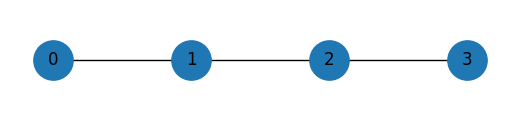

In [2]:
e = [(0,1), (1,2), (2,3)] #list of edges
G = nx.Graph(e)

pos = {0: [0,0], 1: [1,0], 2: [2,0], 3: [3,0]}
fig = plt.figure(1, figsize=(5, 1))
nx.draw(G, with_labels= True, pos=pos, node_size= 800)

Setting attribute to account for the real epidemics in the graph

In [3]:
attrs = {0: {"inf_time": 1, "status": 'recovered'}, 1: {"inf_time": 2, "status": 'recovered'}, 
         2: {"inf_time": 3, "status": 'recovered'}, 3: {"inf_time": math.inf, "status": 'susceptible'}} 
nx.set_node_attributes(G, attrs)

Visualizing the graph with their respectives infection times


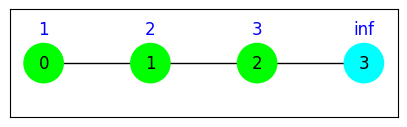

In [4]:
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
state_pos = {n: (x, y + 0.035) for n, (x,y) in pos.items()}

fig = plt.figure(1, figsize=(5, 1.4))
nx.draw_networkx(G, pos, node_size = 800, node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

Partial information available

In [5]:
#First we make a copy of G with the real infection times
G_real = copy.deepcopy(G)

In [6]:
#We exclude the information for nodes 2 and 3
nx.set_node_attributes(G, {2: {"inf_time": math.inf, "status": None}, 3: {"inf_time": math.inf, "status": None}})

Visualizing the graph with only the partial information available

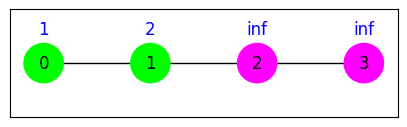

In [7]:
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan', None: 'magenta'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
state_pos = {n: (x, y + 0.035) for n, (x,y) in pos.items()}

fig = plt.figure(1, figsize=(5, 1.4))
nx.draw_networkx(G, pos, node_size = 800, node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

Set an initial feasible tree for G given the observed values

In [8]:
# The feasible tree data structure is a list of lists
# Each element in T_initial is a path in the tree
T_initial = [[0], [1,0]]
print(T_initial)

[[0], [1, 0]]


Start the sampling algorithm

(at each run we plot information about the current tree, choosed operations and so forth in order to manually verify the correctness of the outputs)

In [9]:
infected_nodes = [0,1]
samplings_number = 500

#Set seed for reproducibility
rd.seed(10)

#Initialize class
sampler = TreeSampler(G, T_initial, infected_nodes,flag=1)

#Run
sampling = sampler.run(n_iterations=samplings_number)
print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
print("--------------------------------------------------------------------------------------------")
print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

Sampling trees:   0%|          | 0/500 [00:00<?, ?it/s]

Sampling trees: 100%|██████████| 500/500 [00:00<00:00, 3906.18it/s]

Final Acceptance Rate: 43.20%
Real infection times: {0: 1, 1: 2, 2: 3, 3: inf}
--------------------------------------------------------------------------------------------
Frequency of nodes: {0: 1.0, 1: 1.0, 2: 0.9760479041916168, 3: 0.48502994011976047}


### Plots (visualizing results)
Trace plot

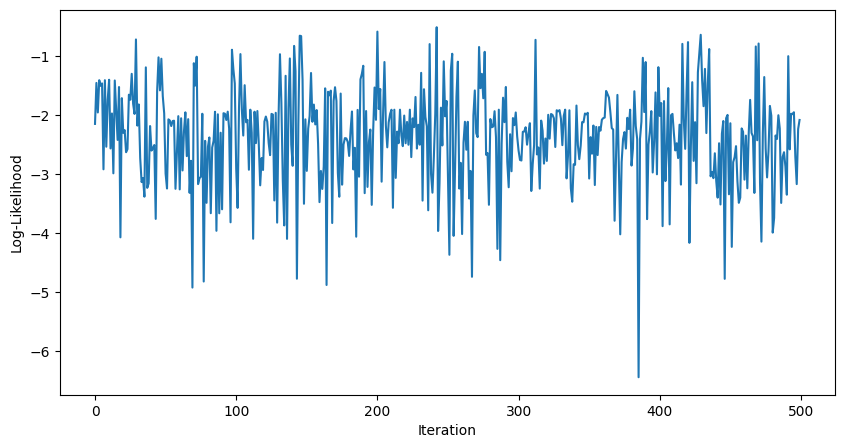

In [10]:
sampler._trace_plot_log_likelihood()

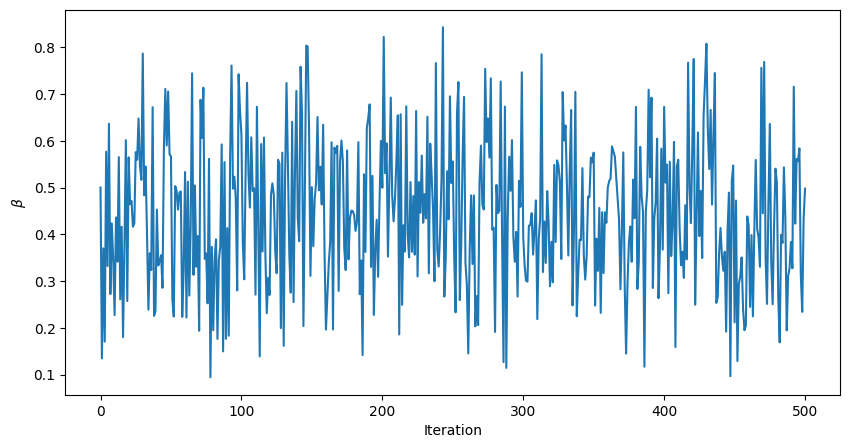

In [11]:
sampler._trace_plot_beta()